In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.simplefilter('ignore')

In [3]:
df=pd.read_csv('/content/Custme_Shopping_Behaviour.csv')

In [4]:
df.head(2)

,customer_id,age,gender,item_purchased,category,purchase_amount,location,size,color,season,review_rating,subscription_status,shipping_type,discount_applied,previous_purchases,payment_method,frequency_of_purchases,age_group,purchase_frequency_days
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,14,Venmo,Fortnightly,Middle-aged,14
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,2,Cash,Fortnightly,Young Adult,14


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_id              3900 non-null   int64  
 1   age                      3900 non-null   int64  
 2   gender                   3900 non-null   object 
 3   item_purchased           3900 non-null   object 
 4   category                 3900 non-null   object 
 5   purchase_amount          3900 non-null   int64  
 6   location                 3900 non-null   object 
 7   size                     3900 non-null   object 
 8   color                    3900 non-null   object 
 9   season                   3900 non-null   object 
 10  review_rating            3900 non-null   float64
 11  subscription_status      3900 non-null   object 
 12  shipping_type            3900 non-null   object 
 13  discount_applied         3900 non-null   object 
 14  previous_purchases      

In [6]:
df.describe()

,customer_id,age,purchase_amount,review_rating,previous_purchases,purchase_frequency_days
count,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.750051,25.351538,89.133077
std,1125.977353,15.207589,23.685392,0.713590,14.447125,119.037566
min,1.000000,18.000000,20.000000,2.500000,1.000000,7.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000,14.000000
50%,1950.500000,44.000000,60.000000,3.800000,25.000000,30.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000,90.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000,365.000000


In [7]:
df.isnull().sum()

,0
customer_id,0
age,0
gender,0
item_purchased,0
category,0
purchase_amount,0
location,0
size,0
color,0
season,0


In [8]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'previous_purchases', 'payment_method',
       'frequency_of_purchases', 'age_group', 'purchase_frequency_days'],
      dtype='object')

In [ ]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [10]:
df.columns=df.columns.str.lower()
df.columns=df.columns.str.replace(" ",'_')
df=df.rename(columns={'purchase_amount_(usd)':'purchase_amount'})

In [11]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'previous_purchases', 'payment_method',
       'frequency_of_purchases', 'age_group', 'purchase_frequency_days'],
      dtype='object')

In [12]:
labels=['Young Adult','Adult','Middle-aged','Senior']
df['age_group']=pd.qcut(df['age'],q=4,labels=labels)

In [13]:
df[['age','age_group']].head(10)

,age,age_group
0,55,Middle-aged
1,19,Young Adult
2,50,Middle-aged
3,21,Young Adult
4,45,Middle-aged
5,46,Middle-aged
6,63,Senior
7,27,Young Adult
8,26,Young Adult
9,57,Middle-aged


In [14]:

frequency_mapping = {
    'Fortnightly': 14,
    'Weekly': 7,
    'Monthly': 30,
    'Quarterly': 90,
    'Bi-Weekly': 14,
    'Annually': 365,
    'Every 3 Months': 90
}

df['purchase_frequency_days'] = df['frequency_of_purchases'].map(frequency_mapping)


In [17]:
def barplot(columns):
  fig,axes=plt.subplots(2,2,figsize=(12,8))
  axes=axes.flatten()
  for i,column in enumerate(columns):
    ax=axes[i]
    count=df[column].value_counts()
    ax.bar(count.index,count,color='green')
    ax.set_xlabel(column)
    ax.set_ylabel(f'count of {column}')
    ax.set_title(f'Total distribution of {column}')
    plt.xticks(ticks=range(0, len(count.index)))
    ax.set_xticklabels(count.index, rotation=90)
    plt.tight_layout()

plt.show()


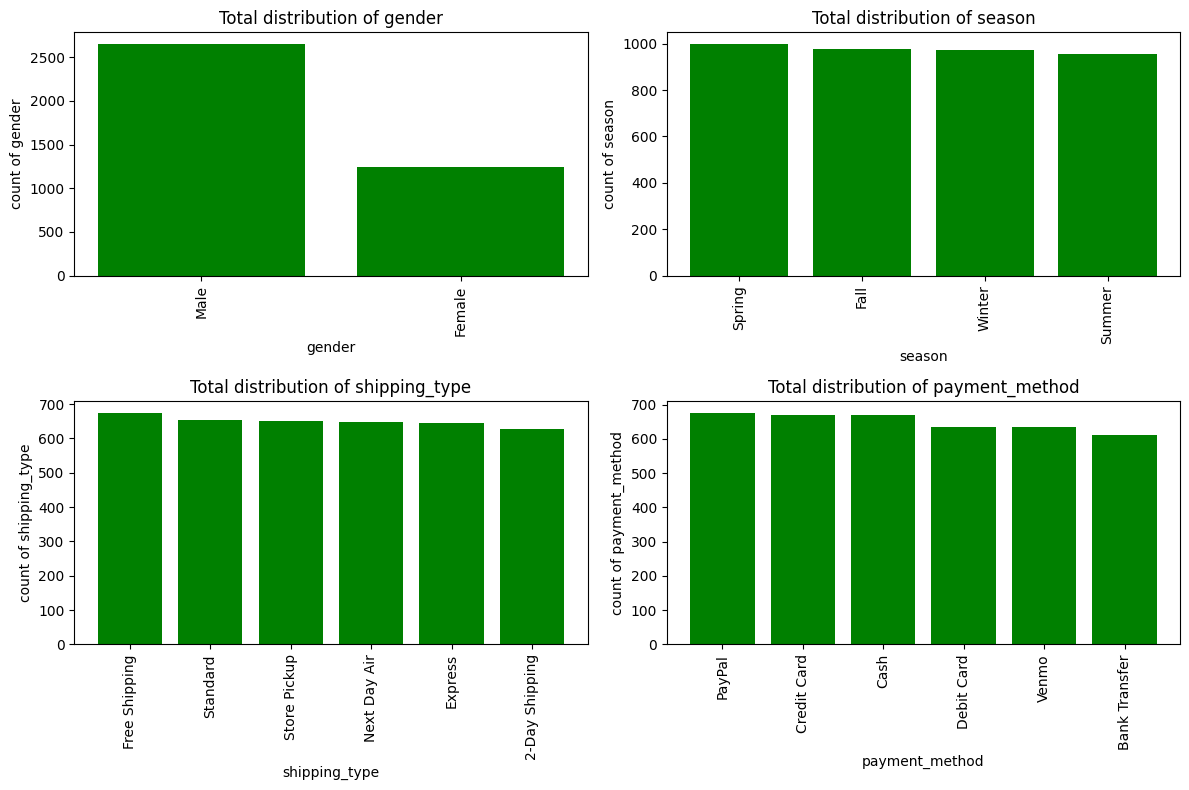

In [18]:
barplot(['gender','season','shipping_type','payment_method'])

In [19]:
def pie_chart(columns,layout='row'):
  num_cols = len(columns)
  if layout == "row" and num_cols == 3:
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))  # 1x3 layout
  elif layout == "grid" and num_cols <= 4:
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))  # 2x2 layout
    axes = axes.flatten()
  for i,column in enumerate(columns):
    ax=axes[i]
    count=df[column].value_counts()
    ax.pie(count,labels=count.index,autopct='%0.1f%%')
    ax.set_title(f'{column}_distribution')
    ax.legend(count.index, title=column, loc="upper left", bbox_to_anchor=(0.95, 0.75))
plt.tight_layout()
plt.show()




<Figure size 640x480 with 0 Axes>

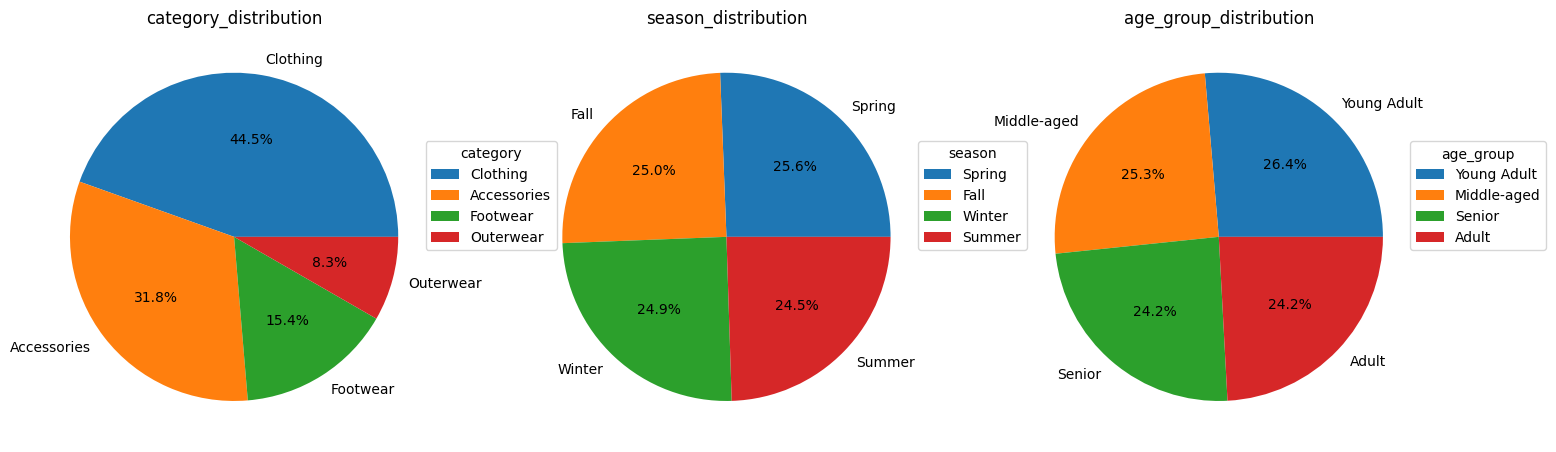

In [20]:
pie_chart(['category','season','age_group'])

In [22]:
df.head(2)

,customer_id,age,gender,item_purchased,category,purchase_amount,location,size,color,season,review_rating,subscription_status,shipping_type,discount_applied,previous_purchases,payment_method,frequency_of_purchases,age_group,purchase_frequency_days
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,14,Venmo,Fortnightly,Middle-aged,14
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,2,Cash,Fortnightly,Young Adult,14


In [63]:
def bar_plot(column1,column2):
  plt.figure(figsize=(14,4))

  plt.subplot(121)
  sns.barplot(data=df,x=column1,y=column2,color='green',hue='gender')
  plt.xlabel(column1)
  plt.ylabel(column2)
  plt.title(f'bar plot of {column1} and {column2}')
plt.show()

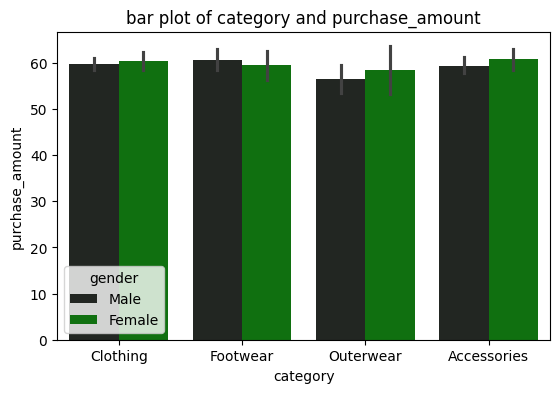

In [64]:
bar_plot('category','purchase_amount')

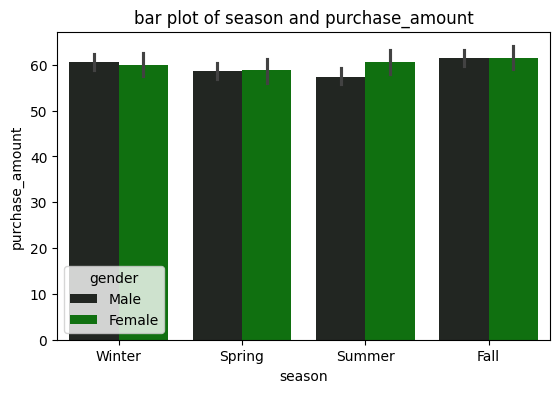

In [65]:
bar_plot('season','purchase_amount')

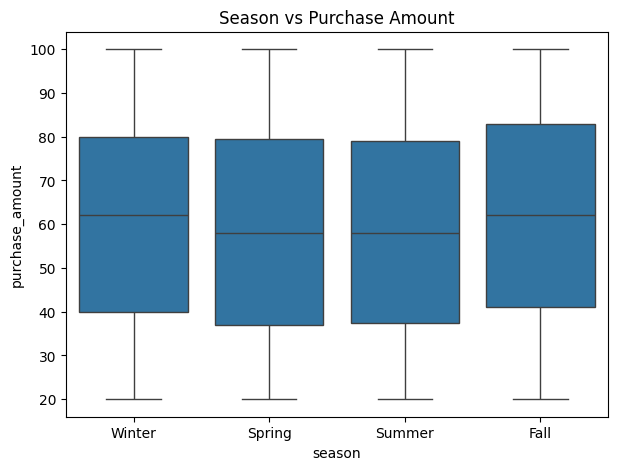

In [52]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x='season', y='purchase_amount')
plt.title('Season vs Purchase Amount')
plt.show()

In [54]:
df.corr(numeric_only=True)

,customer_id,age,purchase_amount,review_rating,previous_purchases,purchase_frequency_days
customer_id,1.000000,-0.004079,0.011048,0.000281,-0.039159,0.005380
age,-0.004079,1.000000,-0.010424,-0.024463,0.040445,0.016544
purchase_amount,0.011048,-0.010424,1.000000,0.029659,0.008063,0.009526
review_rating,0.000281,-0.024463,0.029659,1.000000,0.003555,0.004401
previous_purchases,-0.039159,0.040445,0.008063,0.003555,1.000000,-0.016996
purchase_frequency_days,0.005380,0.016544,0.009526,0.004401,-0.016996,1.000000
